# Network Intrusion Detection - EDA


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
from scipy.stats import ks_2samp
import plotly.graph_objects as go
warnings.filterwarnings('ignore')


sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10


### 2017

In [3]:
files = [
    '../data/2017/Monday-WorkingHours.pcap_ISCX.csv',
    '../data/2017/Tuesday-WorkingHours.pcap_ISCX.csv',
    '../data/2017/Wednesday-workingHours.pcap_ISCX.csv',
    '../data/2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    '../data/2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    '../data/2017/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    '../data/2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '../data/2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
]


dataframes = []
for file in files:
    try:
        df = pd.read_csv(file)
        dataframes.append(df)
        print(f"Loaded {file}: {df.shape[0]:,} rows")
    except FileNotFoundError:
        print(f"File not found: {file}")


df_combined = pd.concat(dataframes, ignore_index=True)
print(f"\n{'='*50}")
print(f"Combined dataset shape: {df_combined.shape}")
print(f"Total flows: {len(df_combined):,}")
print(f"Total features: {df_combined.shape[1]}")

Loaded ../data/2017/Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
Loaded ../data/2017/Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
Loaded ../data/2017/Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows
Loaded ../data/2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
Loaded ../data/2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
Loaded ../data/2017/Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
Loaded ../data/2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
Loaded ../data/2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows

Combined dataset shape: (2830743, 79)
Total flows: 2,830,743
Total features: 79


In [4]:

print("Dataset Info:")
print(f"Shape: {df_combined.shape}")
print(f"\nData Types:")
print(df_combined.dtypes.value_counts())

missing = df_combined.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing Values:")
    print(missing[missing > 0])
else:
    print("\n No missing values!")

print(f"\nInfinite values:")
inf_count = np.sum(np.isinf(df_combined.select_dtypes(include=[np.number])))
print(f"Total infinite values: {inf_count}")
if inf_count > 0:
    for col in df_combined.select_dtypes(include=[np.number]).columns:
        if np.sum(np.isinf(df_combined[col])) > 0:
            print(f"  - {col}: {np.sum(np.isinf(df_combined[col]))} inf values")

Dataset Info:
Shape: (2830743, 79)

Data Types:
int64      54
float64    24
str         1
Name: count, dtype: int64

Missing Values:
Flow Bytes/s    1358
dtype: int64

Infinite values:
Total infinite values: 4376
  - Flow Bytes/s: 1509 inf values
  -  Flow Packets/s: 2867 inf values


In [37]:
print("Cleaning infinite values...")
df = df_combined.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)  

df.columns = df.columns.str.strip()
print(" Data cleaned!\n")

print("Label column name: 'Label'\n")
print("First few rows:")
print(df.head(10))

print("\nColumns:")
print(list(df.columns))

Cleaning infinite values...
 Data cleaned!

Label column name: 'Label'

First few rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             49188              4                  2                       0   
1             49188              1                  2                       0   
2             49188              1                  2                       0   
3             49188              1                  2                       0   
4             49486              3                  2                       0   
5             49486              1                  2                       0   
6             49486              1                  2                       0   
7             49486              1                  2                       0   
8                88            609                  7                       4   
9                88            879                  9                       4   

   Total Length of F

In [38]:
label_counts = df['Label'].value_counts()
label_pct = df['Label'].value_counts(normalize=True) * 100

print("Attack Type Distribution:")
print(f"{'Type':<20} {'Count':>12} {'Percentage':>12}")
print("-" * 45)
for label in label_counts.index:
    print(f"{label:<20} {label_counts[label]:>12,} {label_pct[label]:>11.2f}%")

print(f"\nTotal flows: {len(df):,}")
print(f"Benign flows: {label_counts['BENIGN']:,} ({label_pct['BENIGN']:.2f}%)")
print(f"Attack flows: {len(df) - label_counts['BENIGN']:,} ({100 - label_pct['BENIGN']:.2f}%)")

Attack Type Distribution:
Type                        Count   Percentage
---------------------------------------------
BENIGN                  2,273,097       80.30%
DoS Hulk                  231,073        8.16%
PortScan                  158,930        5.61%
DDoS                      128,027        4.52%
DoS GoldenEye              10,293        0.36%
FTP-Patator                 7,938        0.28%
SSH-Patator                 5,897        0.21%
DoS slowloris               5,796        0.20%
DoS Slowhttptest            5,499        0.19%
Bot                         1,966        0.07%
Web Attack � Brute Force        1,507        0.05%
Web Attack � XSS              652        0.02%
Infiltration                   36        0.00%
Web Attack � Sql Injection           21        0.00%
Heartbleed                     11        0.00%

Total flows: 2,830,743
Benign flows: 2,273,097 (80.30%)
Attack flows: 557,646 (19.70%)


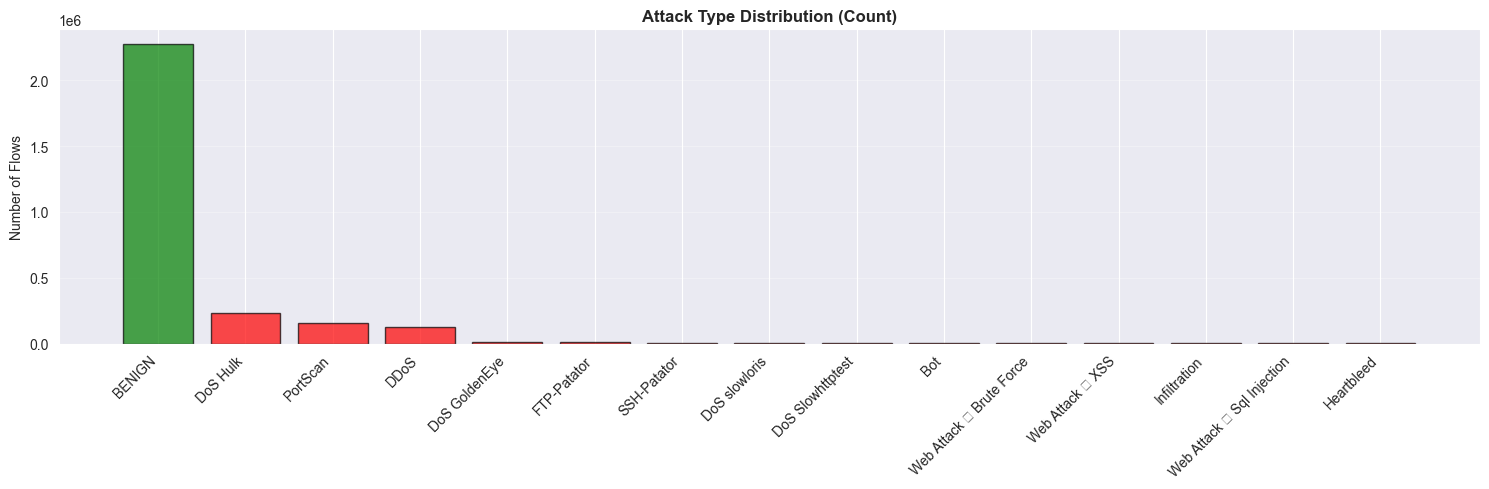

In [39]:
fig, ax = plt.subplots(figsize=(15, 5))

colors = ['green' if x == 'BENIGN' else 'red' for x in label_counts.index]
ax.bar(range(len(label_counts)), label_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_counts.index, rotation=45, ha='right')
ax.set_ylabel('Number of Flows')
ax.set_title('Attack Type Distribution (Count)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

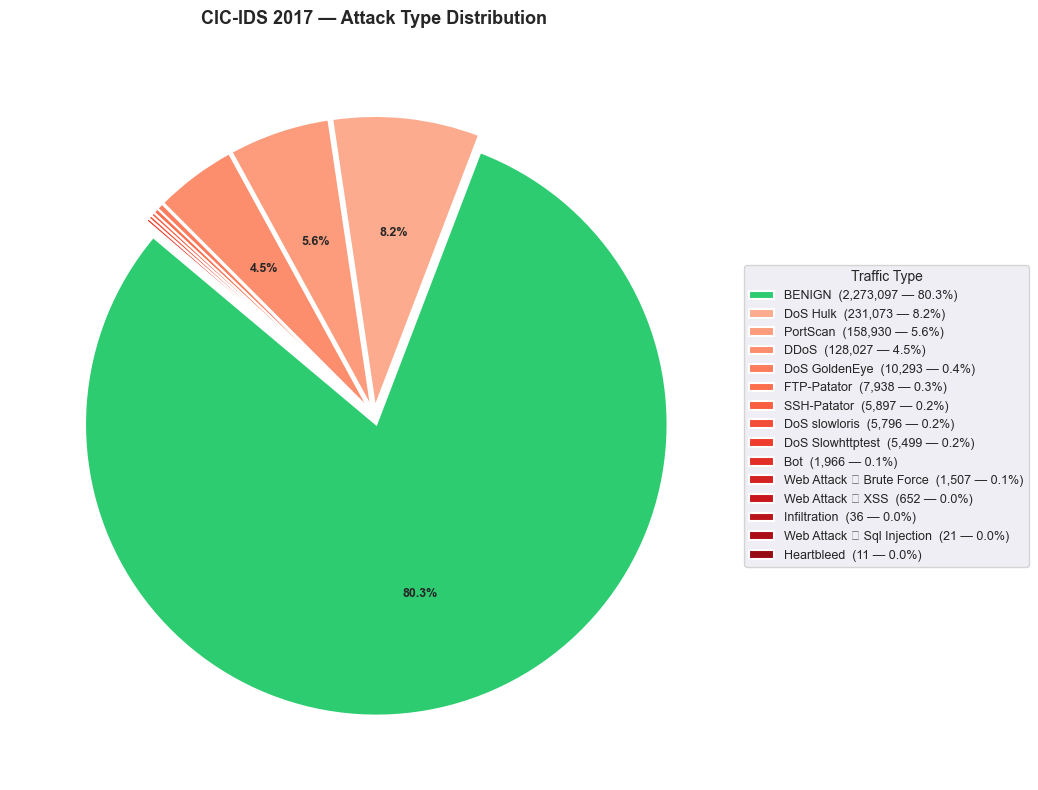

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

n_attacks = len(label_counts) - 1
attack_colors = plt.cm.Reds(np.linspace(0.3, 0.9, n_attacks))
colors = []
for label in label_counts.index:
    if label == 'BENIGN':
        colors.append('#2ecc71')
    else:
        colors.append(attack_colors[list(label_counts.index).index(label) - 1])


explode = [0.03] * len(label_counts)

wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=None,
    colors=colors,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 1 else '',
    startangle=140,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')


legend_labels = [
    f"{label}  ({label_counts[label]:,} — {label_pct[label]:.1f}%)"
    for label in label_counts.index
]
ax.legend(
    wedges,
    legend_labels,
    title="Traffic Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9,
    title_fontsize=10
)

ax.set_title('CIC-IDS 2017 — Attack Type Distribution',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [ ]:
print(df['Label'].unique())


df['label_binary'] = df['Label'].apply(
    lambda x: 0 if x.strip() == 'BENIGN' else 1
)


print(df['label_binary'].value_counts())
print(f"\n0 = BENIGN  : {(df['label_binary']==0).sum():,}")
print(f"1 = ATTACK  : {(df['label_binary']==1).sum():,}")

<ArrowStringArray>
[                    'BENIGN',                'FTP-Patator',
                'SSH-Patator',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
   'Web Attack � Brute Force',           'Web Attack � XSS',
 'Web Attack � Sql Injection',               'Infiltration',
                        'Bot',                       'DDoS',
                   'PortScan']
Length: 15, dtype: str
label_binary
0    2273097
1     557646
Name: count, dtype: int64

0 = BENIGN  : 2,273,097
1 = ATTACK  : 557,646


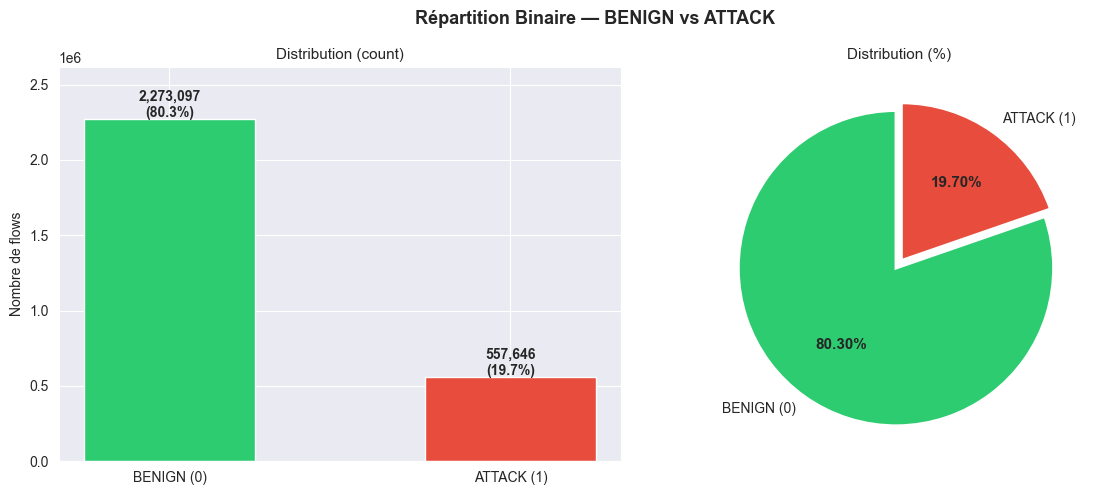

In [55]:
counts = df['label_binary'].value_counts().sort_index()
labels = ['BENIGN (0)', 'ATTACK (1)']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Répartition Binaire — BENIGN vs ATTACK',
             fontsize=13, fontweight='bold')


bars = axes[0].bar(labels, counts.values,
                   color=colors, edgecolor='white',
                   width=0.5)
axes[0].set_title('Distribution (count)', fontsize=11)
axes[0].set_ylabel("Nombre de flows")
for bar, v in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        v + len(df)*0.005,
        f'{v:,}\n({v/len(df)*100:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_ylim(0, max(counts.values) * 1.15)


wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=[0.03, 0.03],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Distribution (%)', fontsize=11)

plt.tight_layout()

plt.show()

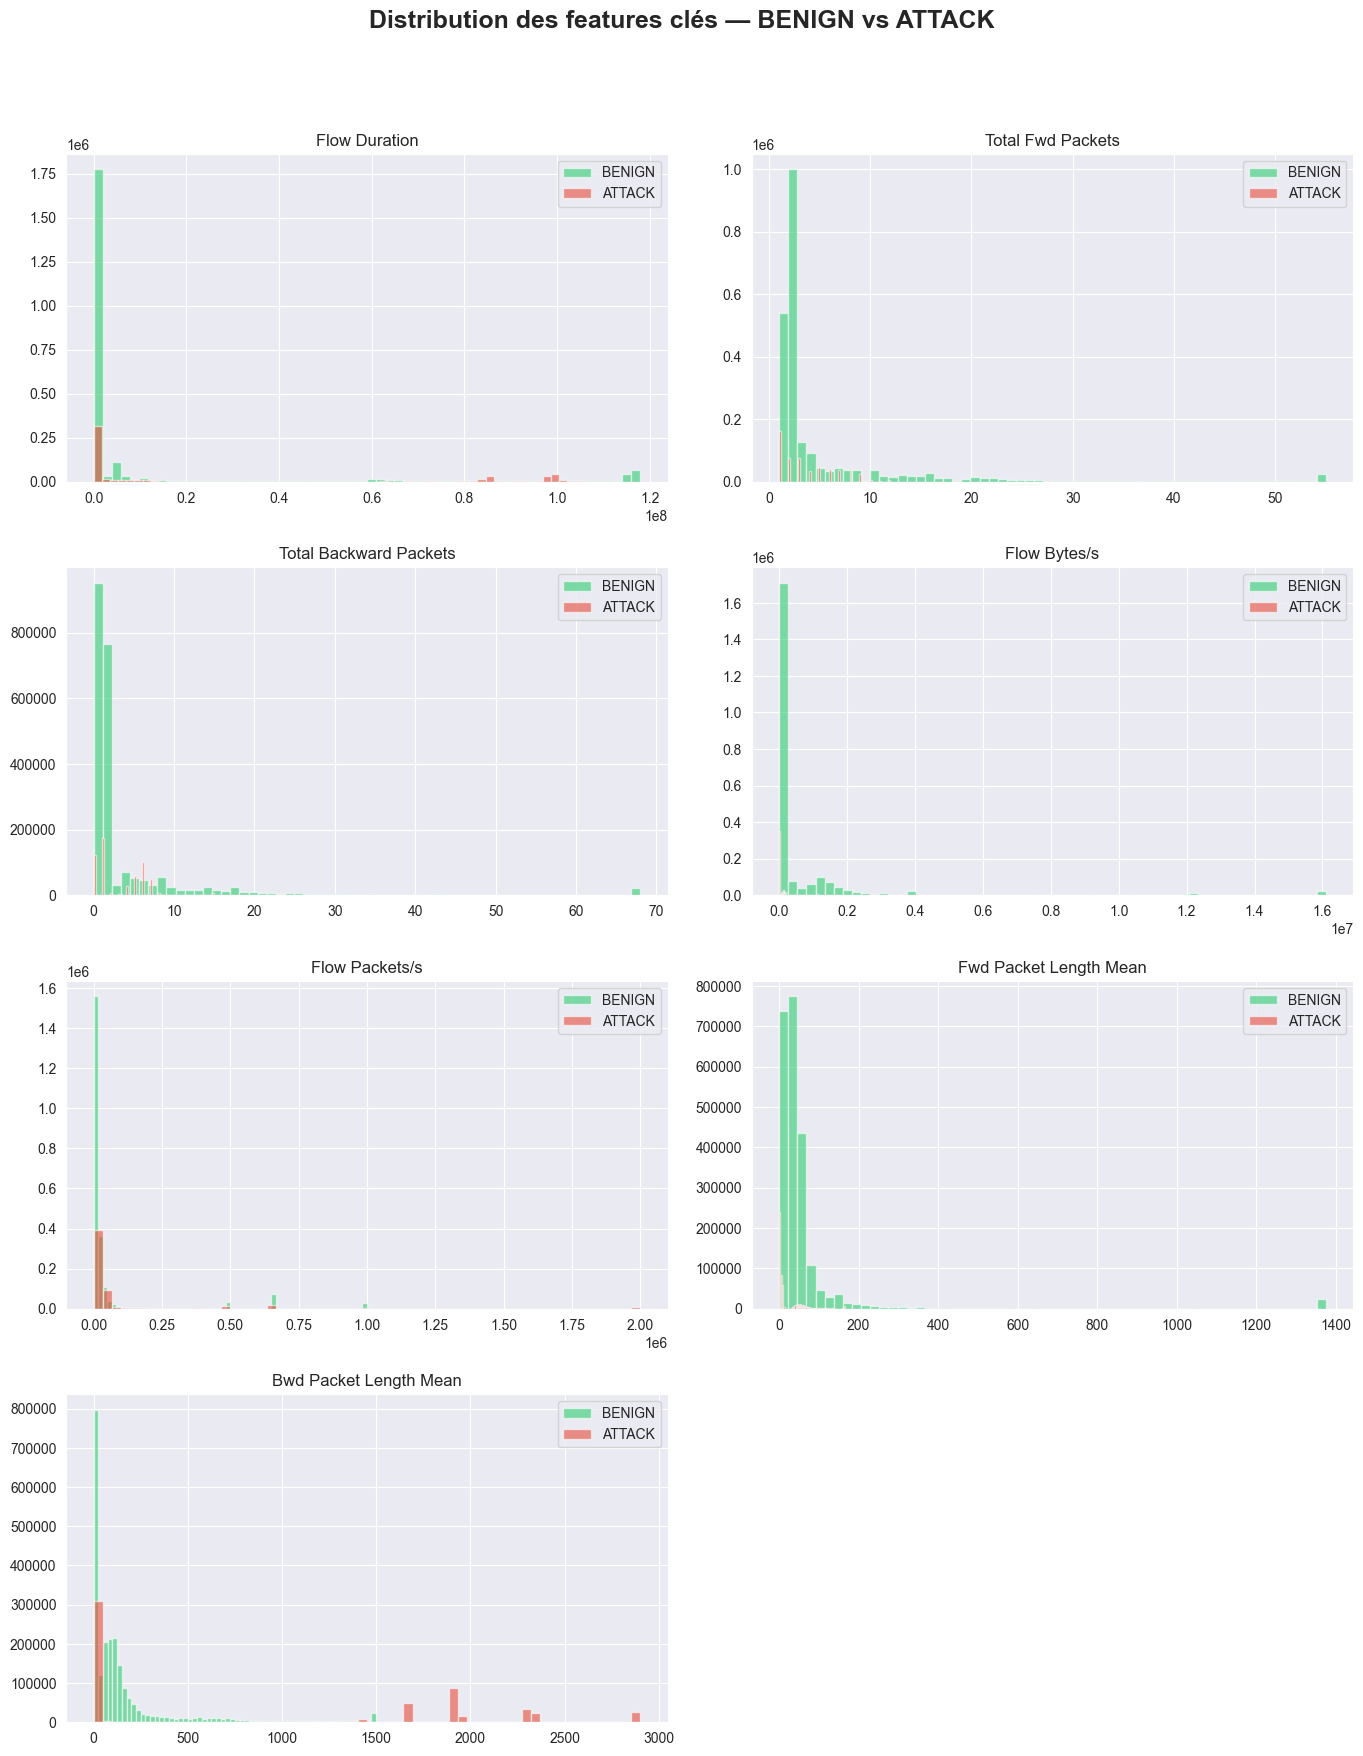

In [ ]:
key_features = ['Flow Duration', 'Total Fwd Packets',
                'Total Backward Packets', 'Flow Bytes/s',
                'Flow Packets/s', 'Fwd Packet Length Mean',
                'Bwd Packet Length Mean']


cols = [c for c in key_features if c in df.columns]
n = len(cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*7, nrows*4.5), dpi=100)
axes = axes.flatten()

fig.suptitle('Distribution des features clés — BENIGN vs ATTACK', fontsize=18, fontweight='bold')

for ax, col in zip(axes, cols):
    benign = df[df['label_binary']==0][col]
    attack = df[df['label_binary']==1][col]

    ax.hist(benign.clip(benign.quantile(0.01), benign.quantile(0.99)),
            bins=60, alpha=0.6, color='#2ecc71', label='BENIGN')
    ax.hist(attack.clip(attack.quantile(0.01), attack.quantile(0.99)),
            bins=60, alpha=0.6, color='#e74c3c', label='ATTACK')
    ax.set_title(col, fontsize=12)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=10)


for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.90)
plt.show()

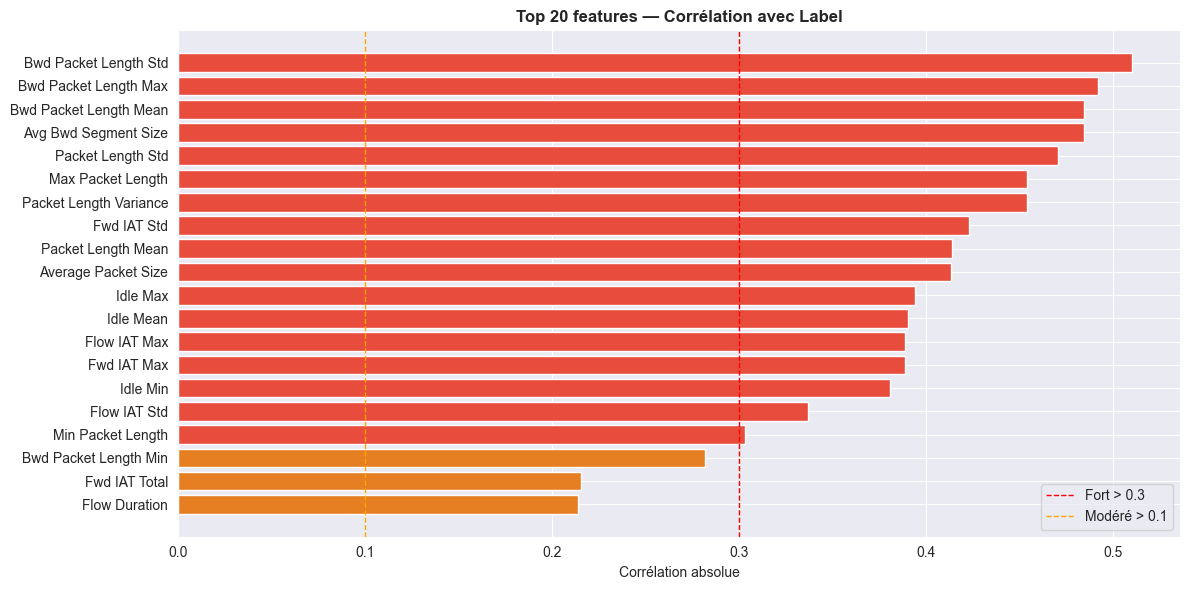

In [50]:
feature_cols = [c for c in df.columns
                if c not in ['Label', 'label_binary']
                and df[c].dtype in ['float64', 'int64']]

correlations = df[feature_cols + ['label_binary']]\
               .corr()['label_binary']\
               .abs()\
               .sort_values(ascending=False)\
               .drop('label_binary')\
               .head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > 0.3 else '#e67e22' if v > 0.1
          else '#2ecc71' for v in correlations.values]

ax.barh(correlations.index[::-1],
        correlations.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0.3, color='red',    linestyle='--', linewidth=1, label='Fort > 0.3')
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Modéré > 0.1')
ax.set_title('Top 20 features — Corrélation avec Label',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Corrélation absolue')
ax.legend()
plt.tight_layout()
plt.show()

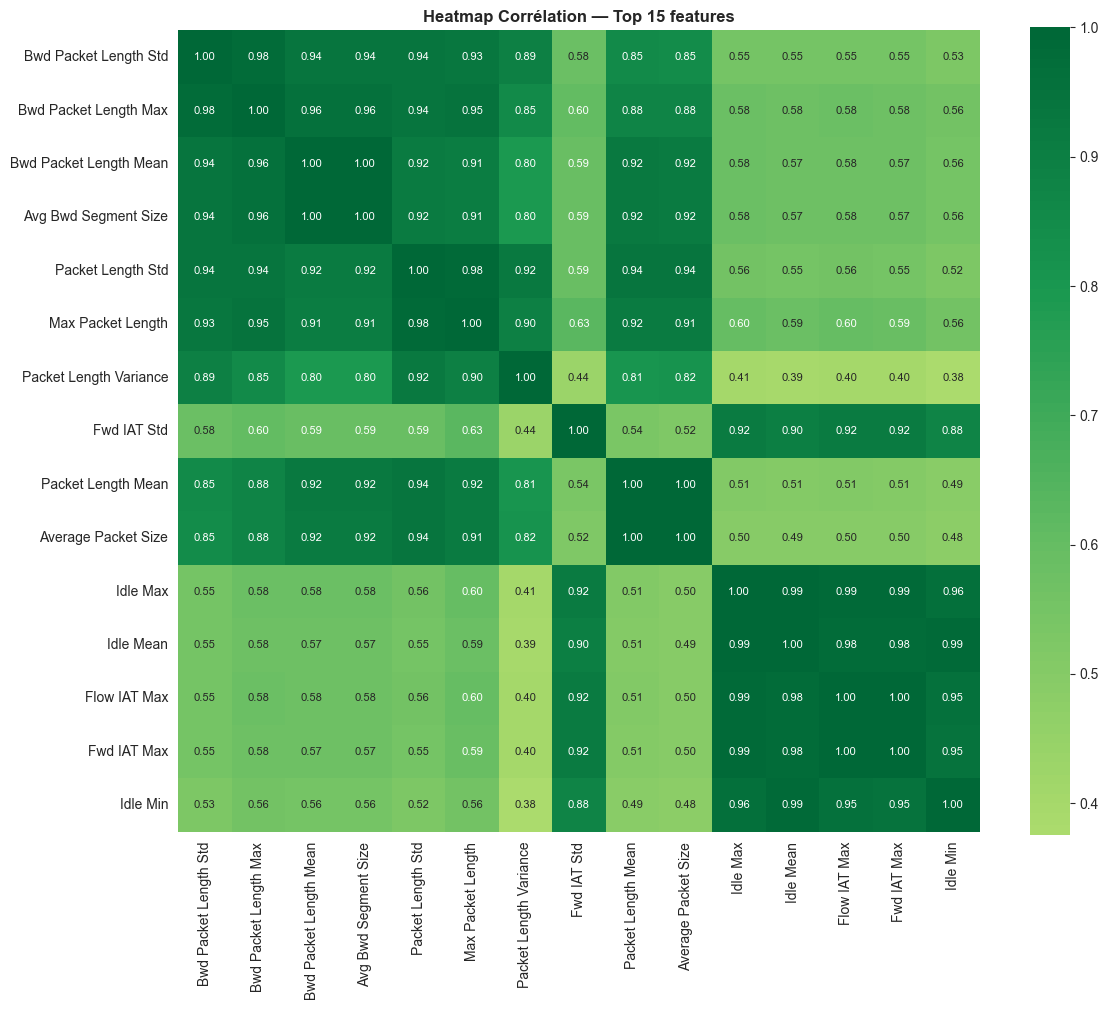

In [ ]:
top15 = correlations.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top15].corr()

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            ax=ax,
            annot_kws={'size': 8})
ax.set_title('Heatmap Corrélation — Top 15 features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

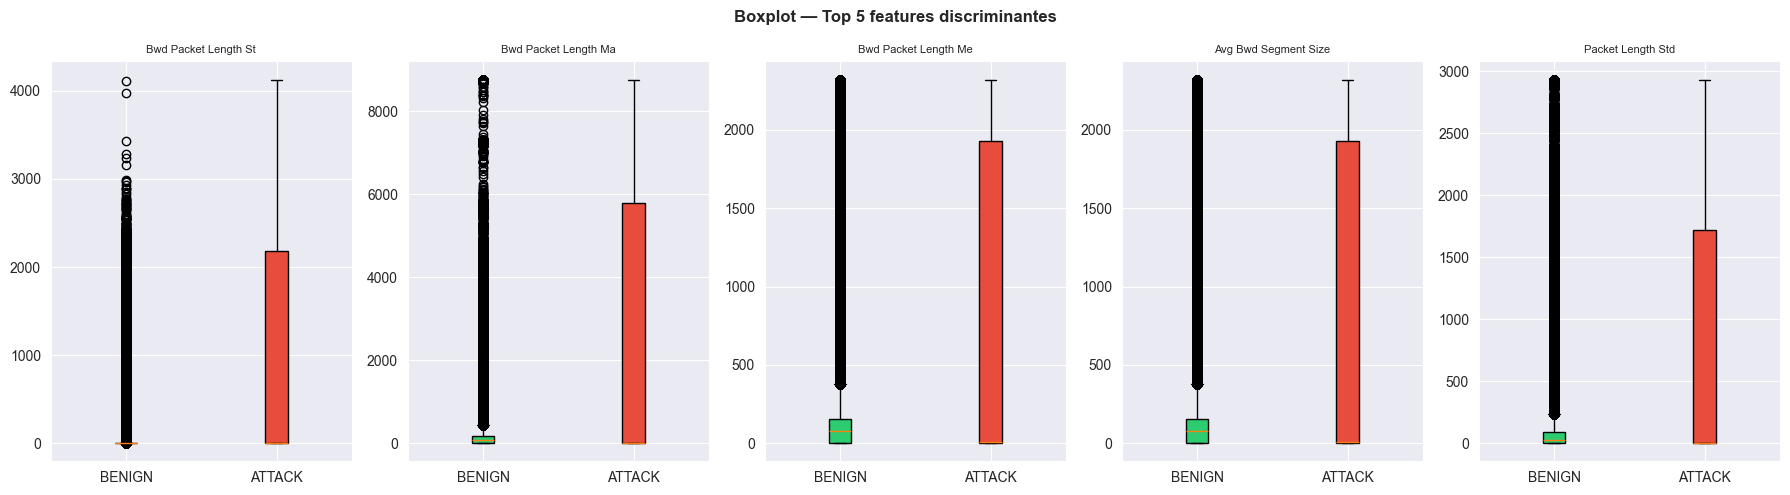

In [52]:
top5 = correlations.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — Top 5 features discriminantes',
             fontsize=12, fontweight='bold')

for ax, col in zip(axes, top5):
    data = [
        df[df['label_binary']==0][col].clip(
            df[col].quantile(0.01), df[col].quantile(0.99)),
        df[df['label_binary']==1][col].clip(
            df[col].quantile(0.01), df[col].quantile(0.99))
    ]
    bp = ax.boxplot(data, labels=['BENIGN', 'ATTACK'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(col[:20], fontsize=8)

plt.tight_layout()
plt.show()

=== Top 20 features discriminantes ===
                    feature  ks_stat  p_value
          Min Packet Length   0.4837      0.0
      Fwd Packet Length Min   0.4746      0.0
      Bwd Packet Length Min   0.4479      0.0
     Init_Win_bytes_forward   0.4404      0.0
      Bwd Packet Length Std   0.4334      0.0
     Packet Length Variance   0.4213      0.0
          Packet Length Std   0.4213      0.0
     Bwd Packet Length Mean   0.4211      0.0
       Avg Bwd Segment Size   0.4211      0.0
      Bwd Packet Length Max   0.4182      0.0
      Fwd Packet Length Max   0.4151      0.0
     Fwd Packet Length Mean   0.4103      0.0
       Avg Fwd Segment Size   0.4103      0.0
          Max Packet Length   0.4083      0.0
        Average Packet Size   0.4019      0.0
         Packet Length Mean   0.4007      0.0
           Destination Port   0.3979      0.0
          Subflow Bwd Bytes   0.3945      0.0
Total Length of Bwd Packets   0.3945      0.0
Total Length of Fwd Packets   0.3702     

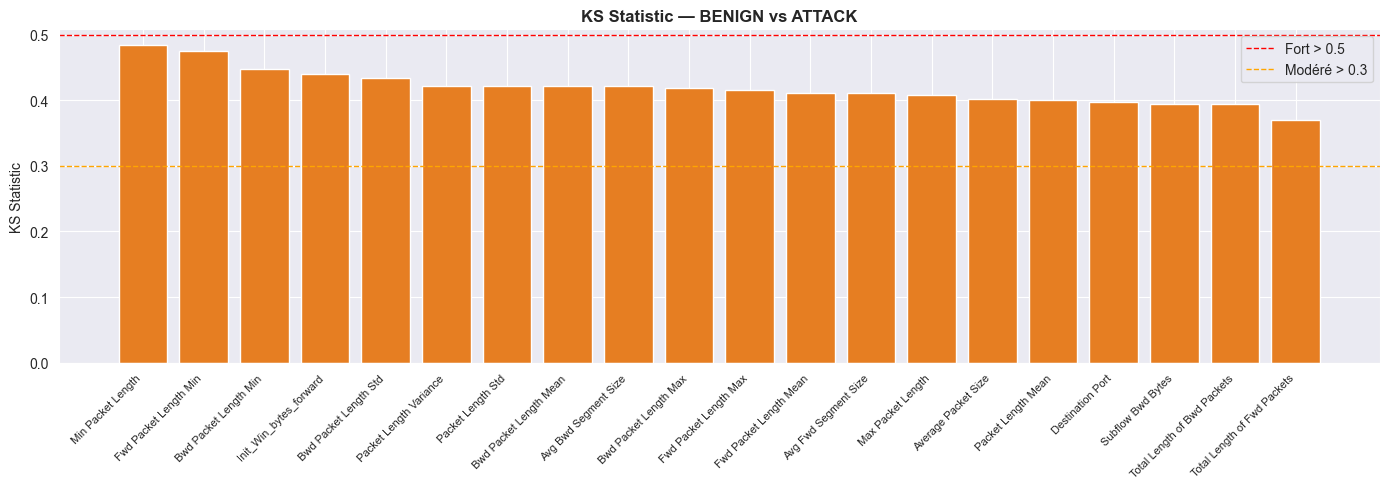

In [53]:
ks_results = []
for col in feature_cols:
    try:
        s, p = ks_2samp(
            df[df['label_binary']==0][col].dropna(),
            df[df['label_binary']==1][col].dropna()
        )
        ks_results.append({'feature': col,
                           'ks_stat': round(s, 4),
                           'p_value': round(p, 6)})
    except:
        pass

ks_df = pd.DataFrame(ks_results)\
          .sort_values('ks_stat', ascending=False)

print("=== Top 20 features discriminantes ===")
print(ks_df.head(20).to_string(index=False))

top20_ks = ks_df.head(20)
colors_ks = ['#e74c3c' if s > 0.5 else '#e67e22'
             for s in top20_ks['ks_stat']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top20_ks['feature'], top20_ks['ks_stat'],
       color=colors_ks, edgecolor='white')
ax.axhline(0.5, color='red',    linestyle='--',
           linewidth=1, label='Fort > 0.5')
ax.axhline(0.3, color='orange', linestyle='--',
           linewidth=1, label='Modéré > 0.3')
ax.set_title('KS Statistic — BENIGN vs ATTACK',
             fontsize=12, fontweight='bold')
ax.set_ylabel('KS Statistic')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 2018


In [4]:
files_2018 = [
    '../data/2018/02-14-2018.csv',
    '../data/2018/02-15-2018.csv',
    '../data/2018/02-16-2018.csv',
    '../data/2018/02-20-2018.csv',
    '../data/2018/02-21-2018.csv',
    '../data/2018/02-22-2018.csv',
    '../data/2018/02-23-2018.csv',
    '../data/2018/02-28-2018.csv',
    '../data/2018/03-01-2018.csv',
    '../data/2018/03-02-2018.csv',
]
 
dataframes_2018 = []
for file in files_2018:
    try:
        df = pd.read_csv(file)
        dataframes_2018.append(df)
        print(f"Loaded {file}: {df.shape[0]:,} rows")
    except FileNotFoundError:
        print(f"File not found: {file}")
 
df_combined_2018 = pd.concat(dataframes_2018, ignore_index=True)
print(f"\n{'='*50}")
print(f"Combined dataset shape: {df_combined_2018.shape}")
print(f"Total flows: {len(df_combined_2018):,}")
print(f"Total features: {df_combined_2018.shape[1]}")

Loaded ../data/2018/02-14-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-15-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-16-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-20-2018.csv: 7,948,748 rows
Loaded ../data/2018/02-21-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-22-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-23-2018.csv: 1,048,575 rows
Loaded ../data/2018/02-28-2018.csv: 613,104 rows
Loaded ../data/2018/03-01-2018.csv: 331,125 rows
Loaded ../data/2018/03-02-2018.csv: 1,048,575 rows

Combined dataset shape: (16233002, 84)
Total flows: 16,233,002
Total features: 84


In [5]:
print("\nDataset Info:")
print(f"Shape: {df_combined_2018.shape}")


cols_to_drop = [col for col in df_combined_2018.columns
                if col.strip() in ['Src IP', 'Src Port', 'Dst IP', 'Flow ID', 'Timestamp']]
if cols_to_drop:
    df_combined_2018 = df_combined_2018.drop(columns=cols_to_drop)


numeric_cols = [col for col in df_combined_2018.columns if col.strip() != 'Label']
for col in numeric_cols:
    df_combined_2018[col] = pd.to_numeric(df_combined_2018[col], errors='coerce')

print(f"\nData Types:")
print(df_combined_2018.dtypes.value_counts())

missing = df_combined_2018.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing Values:")
    print(missing[missing > 0])
    df_combined_2018 = df_combined_2018.fillna(0)
else:
    print("\nNo missing values!")

print(f"\nInfinite values:")
inf_count = np.sum(np.isinf(df_combined_2018.select_dtypes(include=[np.number])))
print(f"Total infinite values: {inf_count}")

print("\nCleaning infinite values...")
df_2018 = df_combined_2018.replace([np.inf, -np.inf], np.nan)
df_2018 = df_2018.fillna(0)

df_2018.columns = df_2018.columns.str.strip()
print("Data cleaned!\n")

print("Label column name: 'Label'\n")
print("First few rows:")
print(df_2018.head(10))

print("\n\nColumns:")
print(list(df_2018.columns))


Dataset Info:
Shape: (16233002, 84)

Data Types:
float64    78
str         1
Name: count, dtype: int64

Missing Values:
Dst Port         59
Protocol         59
Flow Duration    59
Tot Fwd Pkts     59
Tot Bwd Pkts     59
                 ..
Active Min       59
Idle Mean        59
Idle Std         59
Idle Max         59
Idle Min         59
Length: 78, dtype: int64

Infinite values:
Total infinite values: 131799

Cleaning infinite values...
Data cleaned!

Label column name: 'Label'

First few rows:
   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0       0.0       0.0    112641719.0           3.0           0.0   
1       0.0       0.0    112641466.0           3.0           0.0   
2       0.0       0.0    112638623.0           3.0           0.0   
3      22.0       6.0      6453966.0          15.0          10.0   
4      22.0       6.0      8804066.0          14.0          11.0   
5      22.0       6.0      6989341.0          16.0          12.0   
6       0.0       0.0 

In [8]:
label_counts_2018 = df_2018['Label'].value_counts()
label_pct_2018 = df_2018['Label'].value_counts(normalize=True) * 100
 
print("\n\nAttack Type Distribution (2018):")
print(f"{'Type':<25} {'Count':>15} {'Percentage':>12}")
print("-" * 54)
for label in label_counts_2018.index:
    print(f"{label:<25} {label_counts_2018[label]:>15,} {label_pct_2018[label]:>11.2f}%")
 
print(f"\nTotal flows: {len(df_2018):,}")
print(f"Benign flows: {label_counts_2018['Benign']:,} ({label_pct_2018['Benign']:.2f}%)")
print(f"Attack flows: {len(df_2018) - label_counts_2018['Benign']:,} ({100 - label_pct_2018['Benign']:.2f}%)")



Attack Type Distribution (2018):
Type                                Count   Percentage
------------------------------------------------------
Benign                         13,484,708       83.07%
DDOS attack-HOIC                  686,012        4.23%
DDoS attacks-LOIC-HTTP            576,191        3.55%
DoS attacks-Hulk                  461,912        2.85%
Bot                               286,191        1.76%
FTP-BruteForce                    193,360        1.19%
SSH-Bruteforce                    187,589        1.16%
Infilteration                     161,934        1.00%
DoS attacks-SlowHTTPTest          139,890        0.86%
DoS attacks-GoldenEye              41,508        0.26%
DoS attacks-Slowloris              10,990        0.07%
DDOS attack-LOIC-UDP                1,730        0.01%
Brute Force -Web                      611        0.00%
Brute Force -XSS                      230        0.00%
SQL Injection                          87        0.00%
Label                         

In [10]:
benign_count_2018 = label_counts_2018['Benign']
attack_count_2018 = len(df_2018) - benign_count_2018
 
fig1_2018 = go.Figure(data=[go.Pie(
    labels=['Benign', 'Attacks'],
    values=[benign_count_2018, attack_count_2018],
    marker=dict(
        colors=['#2ecc71', '#e74c3c'],
        line=dict(color='white', width=2)
    ),
    textposition='auto',
    textinfo='label+percent',
    textfont=dict(size=16, family="Arial, sans-serif"),
    hovertemplate='<b>%{label}</b><br>Flows: %{value:,}<br>Percentage: %{percent}<extra></extra>'
)])
 
fig1_2018.update_layout(
    title='<b>ISCX 2018 Dataset - Traffic Overview</b>',
    height=500,
    width=700,
    template='plotly_white',
    font=dict(size=12),
    showlegend=True
)
 
fig1_2018.show()

attack_labels_2018 = [label for label in label_counts_2018.index if label != 'Benign']
attack_values_2018 = [label_counts_2018[label] for label in attack_labels_2018]
 
colors_attacks_2018 = [
    '#e74c3c', '#e67e22', '#c0392b', '#f39c12', '#d35400', '#a93226',
    '#cb4335', '#ec7063', '#b7950b', '#d68910', '#ba4a00', '#922b21', '#f1948a', '#a6acaf'
][:len(attack_labels_2018)]
 
fig2_2018 = go.Figure(data=[go.Pie(
    labels=attack_labels_2018,
    values=attack_values_2018,
    marker=dict(
        colors=colors_attacks_2018,
        line=dict(color='white', width=1.5)
    ),
    textposition='auto',
    textinfo='label+percent',
    textfont=dict(size=11, family="Arial, sans-serif"),
    hovertemplate='<b>%{label}</b><br>Flows: %{value:,}<br>Percentage: %{percent}<extra></extra>'
)])
 
fig2_2018.update_layout(
    title=f'<b>Attack Types Distribution 2018 ({100 - label_pct_2018["Benign"]:.1f}% of total flows)</b>',
    height=600,
    width=900,
    template='plotly_white',
    font=dict(size=11),
    showlegend=True
)
 
fig2_2018.show()

In [12]:
df_2018['label_binary'] = df_2018['Label'].apply(
    lambda x: 0 if x.strip() == 'Benign' else 1
)
 
print("\n\n" + "="*50)
print("BINARY CLASSIFICATION (2018)")
print("="*50)
print(df_2018['label_binary'].value_counts())
print(f"\n0 = BENIGN  : {(df_2018['label_binary']==0).sum():,}")
print(f"1 = ATTACK  : {(df_2018['label_binary']==1).sum():,}")



BINARY CLASSIFICATION (2018)
label_binary
0    13484708
1     2748294
Name: count, dtype: int64

0 = BENIGN  : 13,484,708
1 = ATTACK  : 2,748,294


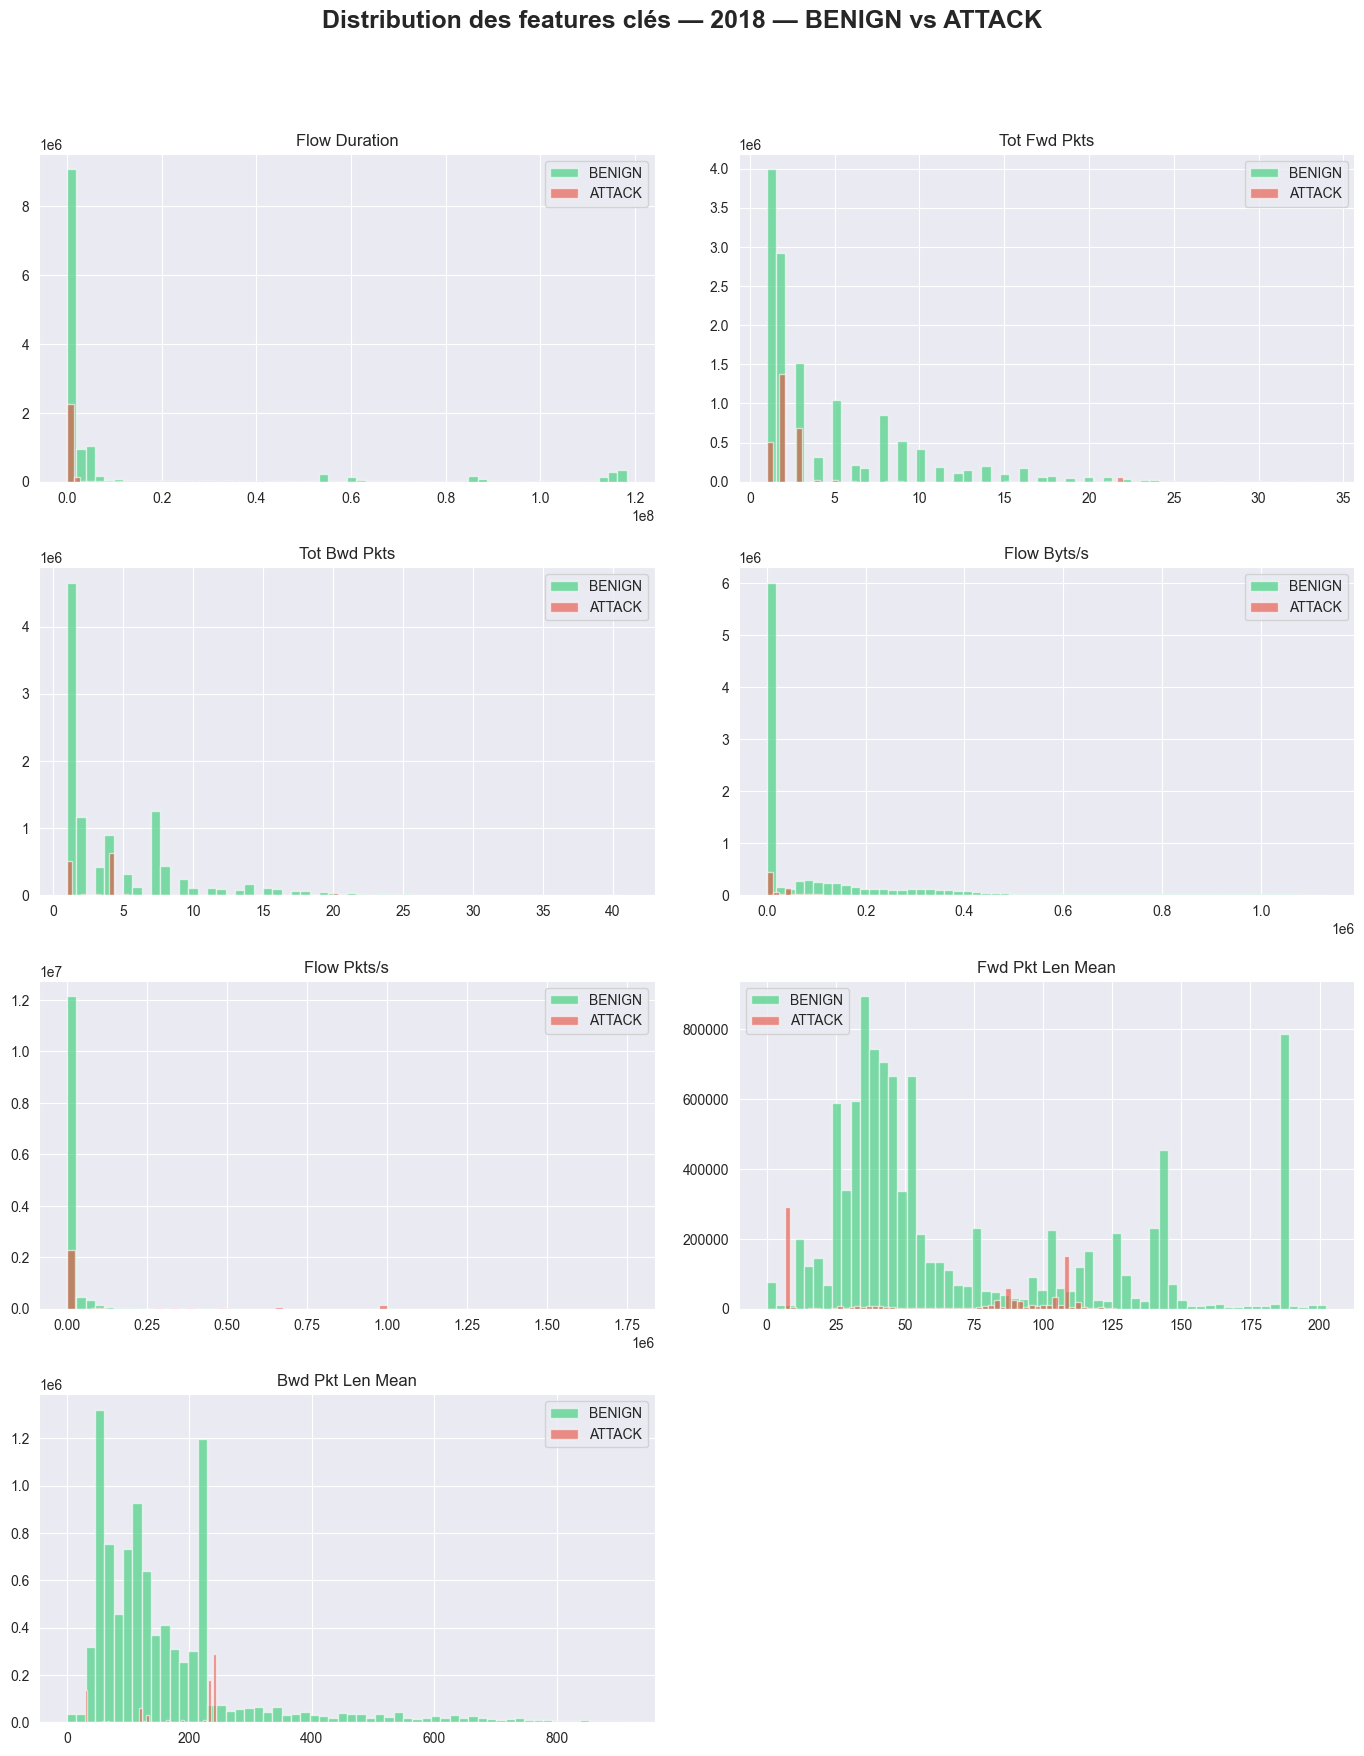

In [14]:
key_features = ['Flow Duration', 'Tot Fwd Pkts',
                'Tot Bwd Pkts', 'Flow Byts/s',
                'Flow Pkts/s', 'Fwd Pkt Len Mean',
                'Bwd Pkt Len Mean']

cols = [c for c in key_features if c in df_2018.columns]
n = len(cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*7, nrows*4.5), dpi=100)
axes = axes.flatten()

fig.suptitle('Distribution des features clés — 2018 — BENIGN vs ATTACK', fontsize=18, fontweight='bold')

for ax, col in zip(axes, cols):
    benign = df_2018[df_2018['label_binary']==0][col]
    attack = df_2018[df_2018['label_binary']==1][col]

    
    benign_clean = benign[(benign > 0) & (benign < benign.quantile(0.99))]
    attack_clean = attack[(attack > 0) & (attack < attack.quantile(0.99))]

    ax.hist(benign_clean, bins=60, alpha=0.6, color='#2ecc71', label='BENIGN')
    ax.hist(attack_clean, bins=60, alpha=0.6, color='#e74c3c', label='ATTACK')
    ax.set_title(col, fontsize=12)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=10)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.90)
plt.show()

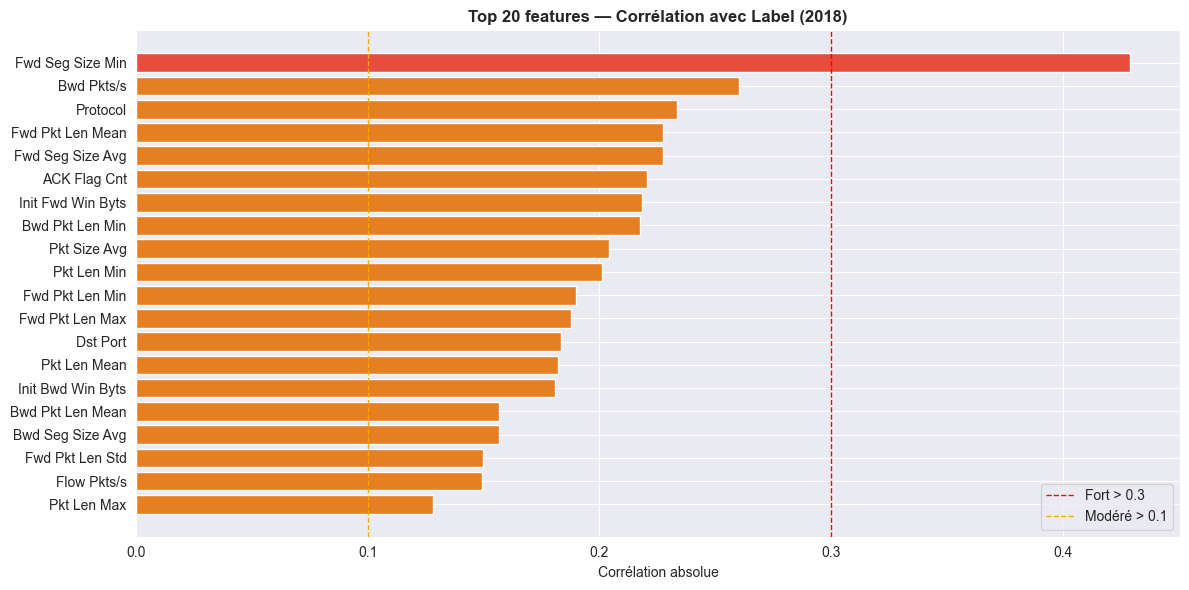

In [15]:
feature_cols_2018 = [c for c in df_2018.columns
                     if c not in ['Label', 'label_binary']
                     and df_2018[c].dtype in ['float64', 'int64']]
 
correlations_2018 = df_2018[feature_cols_2018 + ['label_binary']]\
                    .corr()['label_binary']\
                    .abs()\
                    .sort_values(ascending=False)\
                    .drop('label_binary')\
                    .head(20)
 
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > 0.3 else '#e67e22' if v > 0.1
          else '#2ecc71' for v in correlations_2018.values]
 
ax.barh(correlations_2018.index[::-1],
        correlations_2018.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0.3, color='red',    linestyle='--', linewidth=1, label='Fort > 0.3')
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Modéré > 0.1')
ax.set_title('Top 20 features — Corrélation avec Label (2018)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Corrélation absolue')
ax.legend()
plt.tight_layout()
plt.show()